# RAW PIPELINE — World Air Pollution & AQI (2014–2025)
## Mục tiêu:
### 1) Download toàn bộ dataset từ Kaggle vào thư mục data/raw
### 2) Đọc FULL dữ liệu (không lọc bớt)
### 3) EDA sơ bộ trên raw data để thể hiện chất lượng dữ liệu trước preprocessing

In [27]:
!pip install kaggle pandas pyarrow

In [28]:
pip install kaggle

Note: you may need to restart the kernel to use updated packages.


In [29]:
import subprocess
import glob
from pathlib import Path
import pandas as pd

### Cell 3 — Download dataset bằng Kaggle CLI → data/raw

In [30]:
# Thư mục gốc project & thư mục raw
PROJECT_ROOT = Path(r"C:\Users\ADMIN\python\Project-Urban-DM")
RAW_DIR      = PROJECT_ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

# Dùng kaggle CLI để download & unzip trực tiếp vào data/raw
cmd = [
    "kaggle", "datasets", "download",
    "-d", "ashyou09/world-air-pollution-and-aqi-dataset-20142025",
    "-p", str(RAW_DIR),
    "--unzip"
]
print("▶️ Running:", " ".join(cmd))
subprocess.run(cmd, check=True)

print("\n✅ Download xong. Các file trong data/raw:")
for f in RAW_DIR.iterdir():
    try:
        size_mb = f.stat().st_size / 1e6
        print(f"  - {f.name:40s} {size_mb:6.1f} MB")
    except Exception:
        print(f"  - {f.name}")

▶️ Running: kaggle datasets download -d ashyou09/world-air-pollution-and-aqi-dataset-20142025 -p C:\Users\ADMIN\python\Project-Urban-DM\data\raw --unzip

✅ Download xong. Các file trong data/raw:
  - australia                                   0.0 MB
  - bangladesh                                  0.0 MB
  - brazil                                      0.0 MB
  - china                                       0.0 MB
  - egypt                                       0.0 MB
  - ethiopia                                    0.0 MB
  - france                                      0.0 MB
  - germany                                     0.0 MB
  - global_air_quality_2014_2025.csv           71.9 MB
  - india                                       0.0 MB
  - indonesia                                   0.0 MB
  - iran                                        0.0 MB
  - japan                                       0.0 MB
  - mexico                                      0.0 MB
  - nigeria                       

### Cell 4 — Load FULL dữ liệu global vào DataFrame

In [31]:
from pathlib import Path
import pandas as pd
import glob

RAW_DIR = Path(r"C:\Users\ADMIN\python\Project-Urban-DM\data\raw")

# Lấy tất cả file CSV trong raw (gồm global, country folders, v.v.)
csv_files = glob.glob(str(RAW_DIR / "**" / "*.csv"), recursive=True)
print(f"Tổng số file CSV tìm được: {len(csv_files)}")

dfs = []
for file in csv_files:
    try:
        print("Đang đọc:", file)
        tmp = pd.read_csv(file, low_memory=False)
        dfs.append(tmp)
    except Exception as e:
        print(f"Lỗi khi đọc file {file}: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"\nShape sau khi concat ALL CSV: {df.shape}")
print(f"Tổng số bản ghi: {len(df):,} (~{len(df)/1000:.1f}k)")

Tổng số file CSV tìm được: 52
Đang đọc: C:\Users\ADMIN\python\Project-Urban-DM\data\raw\global_air_quality_2014_2025.csv
Đang đọc: C:\Users\ADMIN\python\Project-Urban-DM\data\raw\australia\australia\australia_air_quality_2014_2025.csv
Đang đọc: C:\Users\ADMIN\python\Project-Urban-DM\data\raw\bangladesh\bangladesh\bangladesh_air_quality_2014_2025.csv
Đang đọc: C:\Users\ADMIN\python\Project-Urban-DM\data\raw\brazil\brazil\brazil_air_quality_2014_2025.csv
Đang đọc: C:\Users\ADMIN\python\Project-Urban-DM\data\raw\china\china\china_air_quality_2014_2025.csv
Đang đọc: C:\Users\ADMIN\python\Project-Urban-DM\data\raw\egypt\egypt\egypt_air_quality_2014_2025.csv
Đang đọc: C:\Users\ADMIN\python\Project-Urban-DM\data\raw\ethiopia\ethiopia\ethiopia_air_quality_2014_2025.csv
Đang đọc: C:\Users\ADMIN\python\Project-Urban-DM\data\raw\france\france\france_air_quality_2014_2025.csv
Đang đọc: C:\Users\ADMIN\python\Project-Urban-DM\data\raw\germany\germany\germany_air_quality_2014_2025.csv
Đang đọc: C:\Us

### Cell 5 — Đếm số dòng raw & kiểm tra missing

In [32]:
n_rows = len(df)          # tương đương df.shape[0]
print(f"Tổng số bản ghi trong raw dataframe: {n_rows:,}")
print(f"Tương đương ~{n_rows/1000:.1f}k records")

print("\nKiểu dữ liệu các cột:")
print(df.dtypes)

Tổng số bản ghi trong raw dataframe: 1,349,280
Tương đương ~1349.3k records

Kiểu dữ liệu các cột:
Country                            str
State                              str
City                               str
Date                               str
PM2.5 (ug/m3)                  float64
PM10 (ug/m3)                   float64
NO (ug/m3)                     float64
NO2 (ug/m3)                    float64
NOx (ppb)                      float64
NH3 (ug/m3)                    float64
CO (mg/m3)                     float64
SO2 (ug/m3)                    float64
O3 (ug/m3)                     float64
Benzene (ug/m3)                float64
Toluene (ug/m3)                float64
Xylene (ug/m3)                 float64
AQI                            float64
AQI_Bucket                         str
Wind_Speed (km/h)              float64
Humidity (%)                   float64
Deforestation_Rate_%           float64
Industry_Growth_%              float64
CO2_Emission_MT                float64
Popu

---
## EDA — Khám phá Raw Data
> Chạy ngay trên `df` raw (chưa preprocessing) để thầy thấy rõ tình trạng dữ liệu.

### Setup — Output directory & imports

In [33]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')

# Relative path — hoạt động cho cả nhóm
# Notebook nằm trong ph01_raw/ (hoặc tương đương), BASE_DIR = project root
BASE_DIR   = Path.cwd().parent
OUTPUT_DIR = BASE_DIR / 'outputs' / 'ph02_eda'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Output dir:', OUTPUT_DIR)

# Chuẩn bị df_eda: parse Date, thêm year
df_eda = df.copy()
df_eda['Date'] = pd.to_datetime(df_eda['Date'], errors='coerce')
if 'year' not in df_eda.columns:
    df_eda['year'] = df_eda['Date'].dt.year

METRIC_COLS = [
    'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO (ug/m3)', 'NO2 (ug/m3)',
    'NH3 (ug/m3)', 'CO (mg/m3)', 'SO2 (ug/m3)', 'O3 (ug/m3)',
    'AQI', 'Wind_Speed (km/h)', 'Humidity (%)'
]
METRIC_COLS = [c for c in METRIC_COLS if c in df_eda.columns]
print('Metric columns found:', METRIC_COLS)

Output dir: c:\Users\ADMIN\python\DATA_FINAL\outputs\ph02_eda
Metric columns found: ['PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO (ug/m3)', 'NO2 (ug/m3)', 'NH3 (ug/m3)', 'CO (mg/m3)', 'SO2 (ug/m3)', 'O3 (ug/m3)', 'AQI', 'Wind_Speed (km/h)', 'Humidity (%)']


### EDA 1 — Thống kê mô tả & phân phối AQI / PM2.5

AQI summary:
count    1.344898e+06
mean     8.597063e+01
std      6.084174e+01
min      4.000000e+00
25%      5.100000e+01
50%      7.000000e+01
75%      9.900000e+01
max      6.720000e+02
Name: AQI, dtype: float64
Saved: 01_descriptive_stats.png


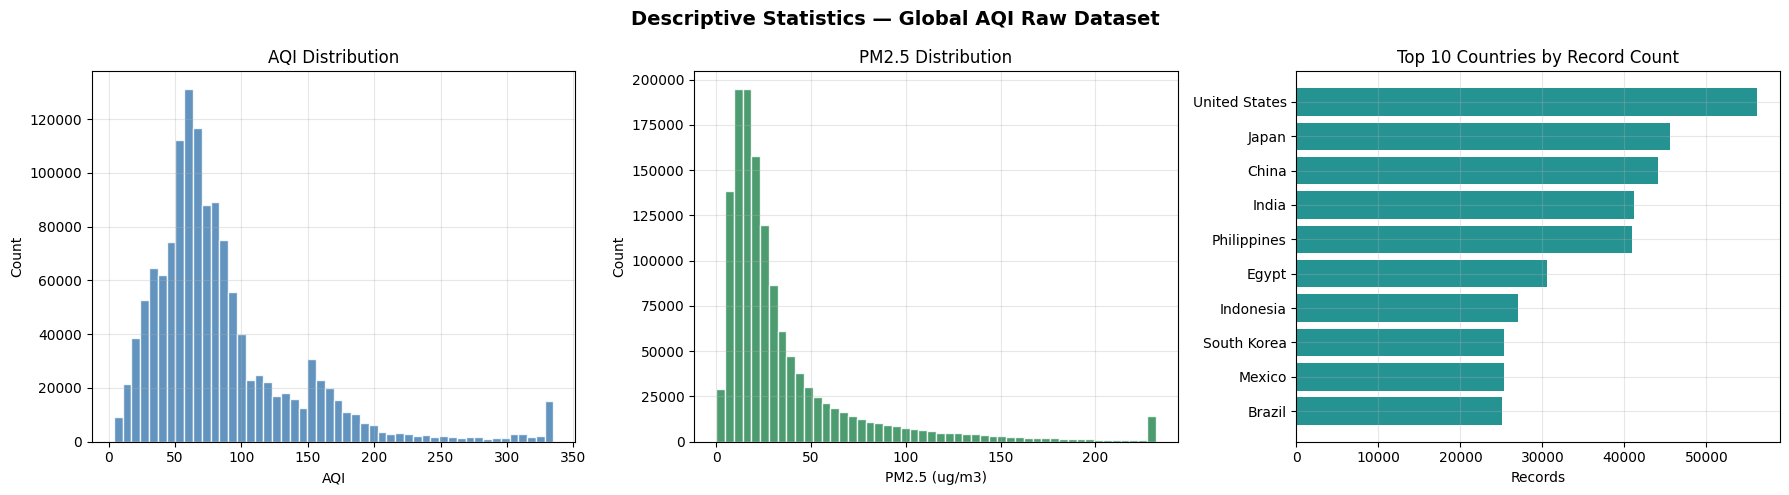

In [34]:
pm25 = df_eda['PM2.5 (ug/m3)'].dropna() if 'PM2.5 (ug/m3)' in df_eda.columns else pd.Series(dtype=float)

print('AQI summary:')
print(df_eda['AQI'].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Descriptive Statistics — Global AQI Raw Dataset', fontsize=14, fontweight='bold')

axes[0].hist(df_eda['AQI'].dropna().clip(upper=df_eda['AQI'].quantile(0.99)),
             bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('AQI Distribution')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

if not pm25.empty:
    axes[1].hist(pm25.clip(upper=pm25.quantile(0.99)),
                 bins=50, color='seagreen', edgecolor='white', alpha=0.85)
    axes[1].set_title('PM2.5 Distribution')
    axes[1].set_xlabel('PM2.5 (ug/m3)')
    axes[1].set_ylabel('Count')
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'PM2.5 column not found', ha='center', va='center')
    axes[1].set_title('PM2.5 Distribution')

country_counts = df_eda['Country'].value_counts().head(10).sort_values()
axes[2].barh(country_counts.index, country_counts.values, color='teal', alpha=0.85)
axes[2].set_title('Top 10 Countries by Record Count')
axes[2].set_xlabel('Records')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_descriptive_stats.png', dpi=150, bbox_inches='tight')
print('Saved: 01_descriptive_stats.png')
plt.show()

### EDA 2 — Top thành phố ô nhiễm nhất (mean AQI)

Top 10 cities by mean AQI (min 30 records):
   Country        City   mean_aqi  record_count
     India    Ludhiana 300.090278           288
     India  Hazaribagh 292.909722           288
     India    Amritsar 290.319444           288
Bangladesh     Gazipur 289.743056           288
Bangladesh       Dhaka 289.493056           288
     India     Patiala 289.131944           288
     India     Panipat 286.506944           288
     India      Dwarka 285.451389           288
Bangladesh Narayanganj 283.409722           288
     India   Ghaziabad 283.118056           288
Saved: 02_top_polluted_cities.png


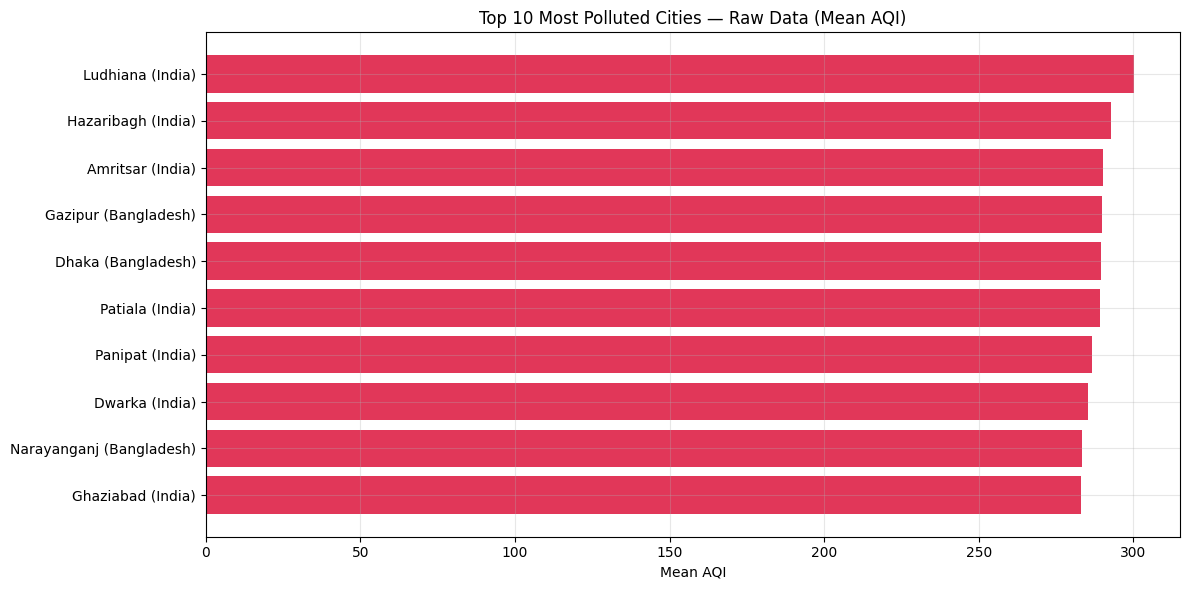

In [35]:
city_aqi = (
    df_eda.groupby(['Country', 'City'], as_index=False)
    .agg(mean_aqi=('AQI', 'mean'), record_count=('AQI', 'count'))
    .query('record_count >= 30')
    .sort_values('mean_aqi', ascending=False)
)

print('Top 10 cities by mean AQI (min 30 records):')
print(city_aqi.head(10).to_string(index=False))

top10 = city_aqi.head(10).sort_values('mean_aqi')
labels = top10['City'] + ' (' + top10['Country'] + ')'

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(labels, top10['mean_aqi'], color='crimson', alpha=0.85)
ax.set_title('Top 10 Most Polluted Cities — Raw Data (Mean AQI)')
ax.set_xlabel('Mean AQI')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_top_polluted_cities.png', dpi=150, bbox_inches='tight')
print('Saved: 02_top_polluted_cities.png')
plt.show()

### EDA 3 — Độ phủ dữ liệu theo quốc gia

Saved: 03_country_city_coverage.png


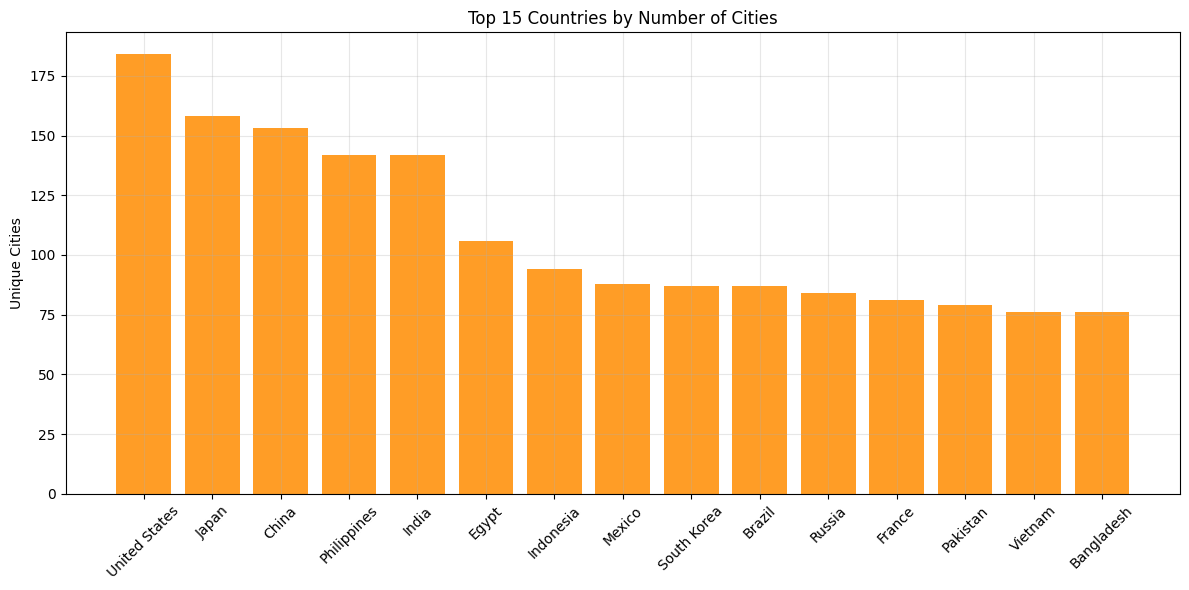

In [36]:
country_city = (
    df_eda.groupby('Country')['City']
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(country_city.index, country_city.values, color='darkorange', alpha=0.85)
ax.set_title('Top 15 Countries by Number of Cities')
ax.set_ylabel('Unique Cities')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_country_city_coverage.png', dpi=150, bbox_inches='tight')
print('Saved: 03_country_city_coverage.png')
plt.show()

### EDA 4 — Ma trận tương quan (Pearson & Spearman)

Saved: 04_correlation_matrices.png


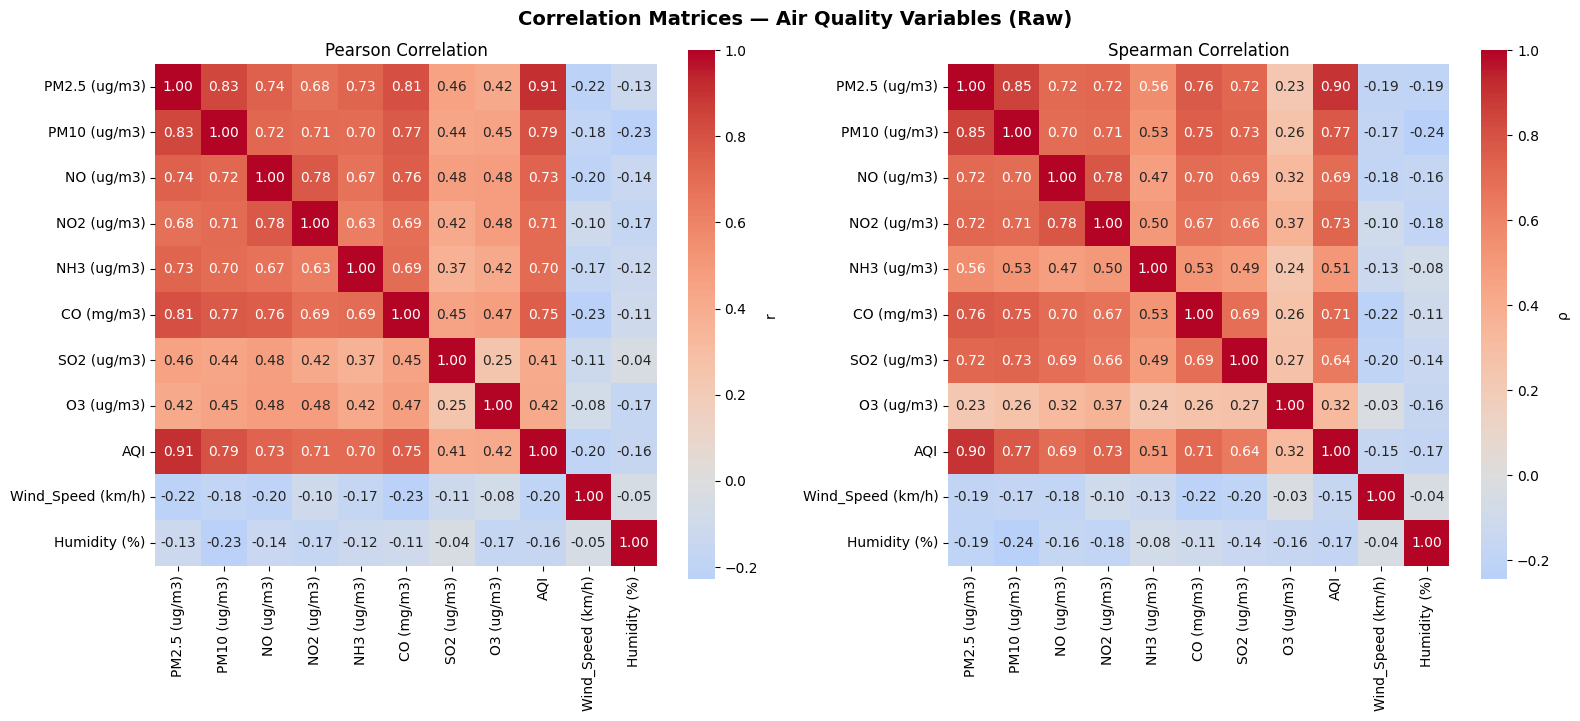

In [37]:
corr_df = df_eda[METRIC_COLS].dropna(how='all')

if len(corr_df) > 10 and len(METRIC_COLS) >= 2:
    pearson_corr  = corr_df.corr(method='pearson')
    spearman_corr = corr_df.corr(method='spearman')

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Correlation Matrices — Air Quality Variables (Raw)', fontsize=14, fontweight='bold')

    sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=axes[0], square=True, cbar_kws={'label': 'r'})
    axes[0].set_title('Pearson Correlation')

    sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=axes[1], square=True, cbar_kws={'label': 'ρ'})
    axes[1].set_title('Spearman Correlation')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '04_correlation_matrices.png', dpi=150, bbox_inches='tight')
    print('Saved: 04_correlation_matrices.png')
    plt.show()
else:
    print('Not enough numeric data for correlation analysis.')

### EDA 5 — Xu hướng AQI theo thời gian (Daily mean)

Saved: 05_time_series_decomposition.png


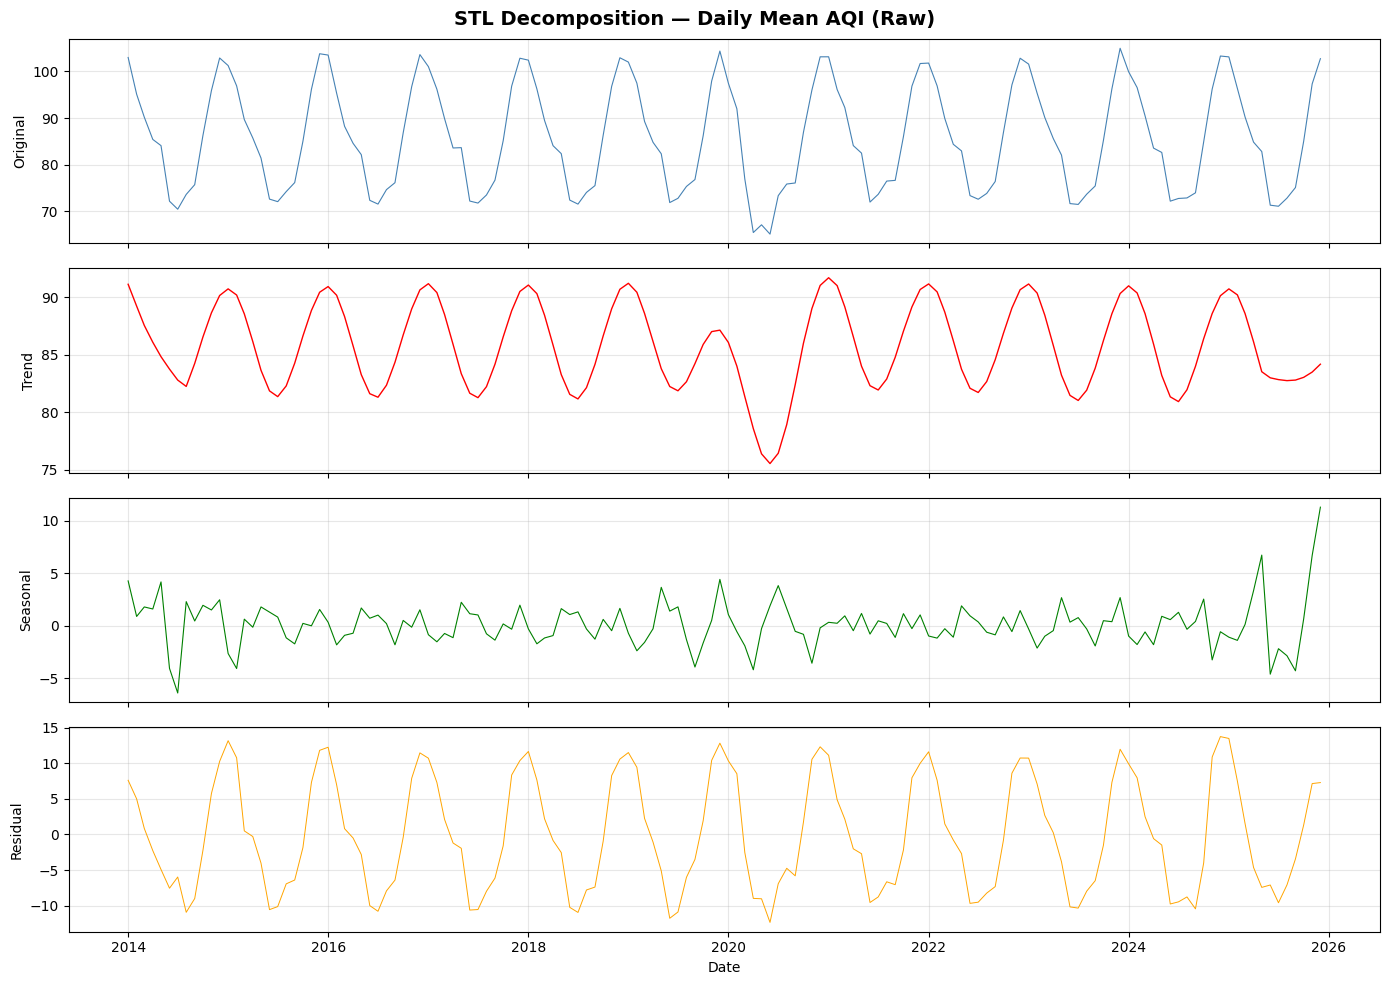


ADF Statistic : -3.5426
p-value       : 0.0070
Result        : Stationary
Saved: 06_fft_frequency_analysis.png


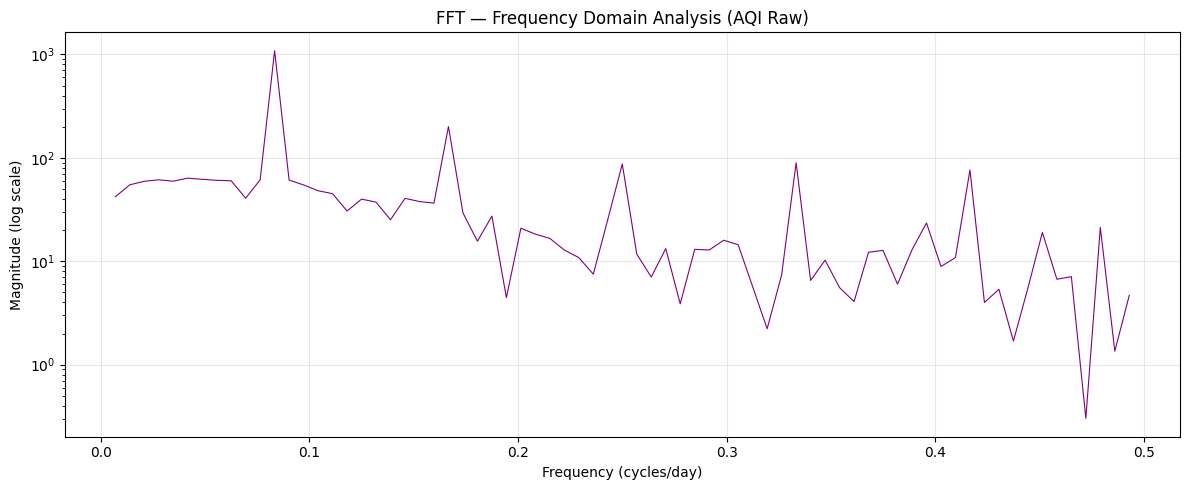

In [38]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from scipy.signal import detrend
from scipy.fft import fft

ts = (
    df_eda.groupby('Date')['AQI']
    .mean()
    .sort_index()
    .dropna()
)

if len(ts) >= 60:
    stl_period = 365 if len(ts) >= 365 else 7
    stl    = STL(ts, period=stl_period, seasonal=7)
    result = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    fig.suptitle('STL Decomposition — Daily Mean AQI (Raw)', fontsize=14, fontweight='bold')
    axes[0].plot(ts.index, ts.values, color='steelblue', linewidth=0.8)
    axes[0].set_ylabel('Original');  axes[0].grid(True, alpha=0.3)
    axes[1].plot(result.trend.index, result.trend, color='red', linewidth=1.0)
    axes[1].set_ylabel('Trend');     axes[1].grid(True, alpha=0.3)
    axes[2].plot(result.seasonal.index, result.seasonal, color='green', linewidth=0.8)
    axes[2].set_ylabel('Seasonal');  axes[2].grid(True, alpha=0.3)
    axes[3].plot(result.resid.index, result.resid, color='orange', linewidth=0.7)
    axes[3].set_ylabel('Residual');  axes[3].set_xlabel('Date'); axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '05_time_series_decomposition.png', dpi=150, bbox_inches='tight')
    print('Saved: 05_time_series_decomposition.png')
    plt.show()

    adf = adfuller(ts.dropna())
    print(f'\nADF Statistic : {adf[0]:.4f}')
    print(f'p-value       : {adf[1]:.4f}')
    print(f'Result        : {"Stationary" if adf[1] < 0.05 else "Non-stationary"}')

    fft_vals  = np.abs(fft(detrend(ts.values)))
    fft_freqs = np.fft.fftfreq(len(ts))
    half      = len(fft_freqs) // 2

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.semilogy(fft_freqs[1:half], fft_vals[1:half], color='purple', linewidth=0.8)
    ax.set_xlabel('Frequency (cycles/day)')
    ax.set_ylabel('Magnitude (log scale)')
    ax.set_title('FFT — Frequency Domain Analysis (AQI Raw)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '06_fft_frequency_analysis.png', dpi=150, bbox_inches='tight')
    print('Saved: 06_fft_frequency_analysis.png')
    plt.show()
else:
    print(f'Not enough time points for STL. Current length: {len(ts)}')

### EDA 6 — Việt Nam: top thành phố theo mean AQI

Vietnam cities by mean AQI:
            City   mean_aqi  record_count
           Hanoi 142.104167           288
       Hai Phong 132.756944           288
     Thai Nguyen 129.013889           288
Ho Chi Minh City 127.798611           288
        Bac Ninh 127.562500           288
      Quang Ninh 127.527778           288
     Thu Dau Mot 114.284722           288
        Bien Hoa 113.972222           288
        Thuan An 112.652778           288
           Di An 111.618056           288
Saved: 07_vietnam_top_cities.png


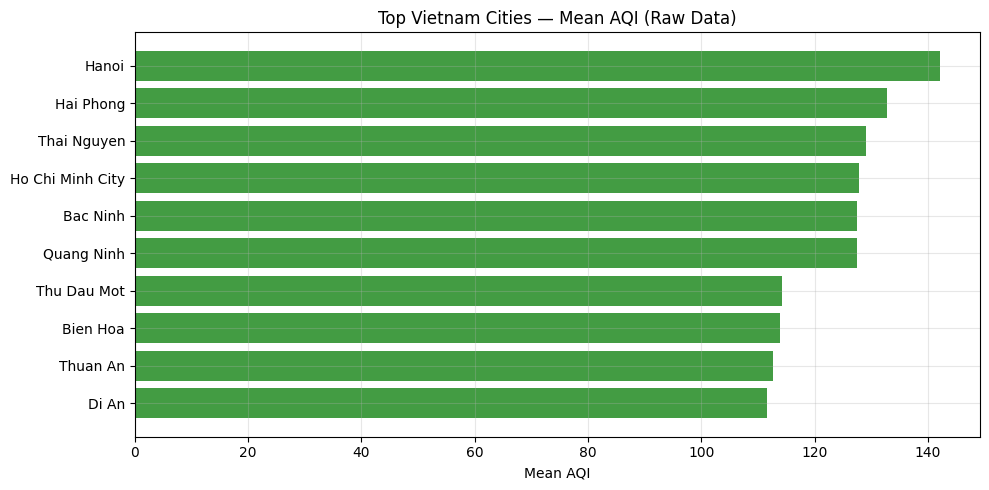

In [39]:
vn_df = df_eda[df_eda['Country'].astype(str).str.lower() == 'vietnam'].copy()

if not vn_df.empty:
    vn_city = (
        vn_df.groupby('City', as_index=False)
        .agg(mean_aqi=('AQI', 'mean'), record_count=('AQI', 'count'))
        .sort_values('mean_aqi', ascending=False)
    )
    print('Vietnam cities by mean AQI:')
    print(vn_city.head(10).to_string(index=False))

    top_vn = vn_city.head(10).sort_values('mean_aqi')
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(top_vn['City'], top_vn['mean_aqi'], color='forestgreen', alpha=0.85)
    ax.set_title('Top Vietnam Cities — Mean AQI (Raw Data)')
    ax.set_xlabel('Mean AQI')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '07_vietnam_top_cities.png', dpi=150, bbox_inches='tight')
    print('Saved: 07_vietnam_top_cities.png')
    plt.show()
else:
    print('Vietnam data not found in dataset.')

### EDA Summary

In [40]:
print('=' * 60)
print('EDA SUMMARY — Raw Data')
print('=' * 60)
print(f'Output directory : {OUTPUT_DIR}')
print('Generated files  :')
for f in sorted(OUTPUT_DIR.glob('*.png')):
    print(f'  {f.name}')
print('=' * 60)

EDA SUMMARY — Raw Data
Output directory : c:\Users\ADMIN\python\DATA_FINAL\outputs\ph02_eda
Generated files  :
  01_descriptive_stats.png
  02_top_polluted_cities.png
  03_country_city_coverage.png
  04_correlation_matrices.png
  05_time_series_decomposition.png
  06_fft_frequency_analysis.png
  07_vietnam_top_cities.png
